# Mosaic of diagnostics

CLERO is fast! A scan over parameter space that would take thousands of GCM runs takes seconds. As an example, here let's a `P_rot` × `P0` grid of TRAPPIST-1e-like climates spanning the core domain in one batched call, compute nine climate diagnostics for each, and plot them as a 3 × 3 mosaic.

With a GPU we use a 100 × 100 grid, 10,000 planets. On an H100 the prediction takes about 3.5 s and the nine diagnostics about 5 s, so the whole grid is done in under 10 s. The grid needs about 10 GB of RAM. Without CUDA the notebook runs a 20 × 20 grid on the CPU.

In [1]:
import time

import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
import torch

from clero import Emulator, TRAPPIST1E
from clero.climate_analysis import latitude_centers, latitude_weights, pressure_levels


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GRID_SIZE = 100 if DEVICE == "cuda" else 20
BATCH_SIZE = 2048 if DEVICE == "cuda" else 256

P_ROT_DAYS = np.geomspace(1.0, 200.0, GRID_SIZE)  # core domain
P0_BAR = np.geomspace(0.5, 5.0, GRID_SIZE)      # core domain
prot_grid, p0_grid = np.meshgrid(P_ROT_DAYS, P0_BAR)

BASE_INPUTS = {**TRAPPIST1E, "CO2": 0.0, "CH4": 0.0, "GCM": "exocam"}
INPUTS = [
    {**BASE_INPUTS, "P_rot": float(prot), "P0": float(p0)}
    for prot, p0 in zip(prot_grid.ravel(), p0_grid.ravel())
]

FIELDS = ["surface_temperature", "asr", "olr"] + [
    f"{base}_{level}"
    for base in ("specific_humidity", "u", "v", "cloud_fraction")
    for level in range(10)
]

print(f"device: {DEVICE}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))
print(f"cases: {len(INPUTS):,}")


device: cpu
cases: 400


## Predict the grid

`Emulator(device="cuda")` runs the model in torch on the GPU and returns NumPy arrays. We request only the fields the diagnostics need.

In [3]:
emu = Emulator(device=DEVICE)

start = time.perf_counter()
pred = emu.predict(INPUTS, fields=FIELDS, batch_size=BATCH_SIZE)
predict_seconds = time.perf_counter() - start

print(f"prediction time: {predict_seconds:.2f} s")


prediction time: 0.87 s


## Compute the nine diagnostics

Global-mean surface temperature, nightside OLR, Bond albedo, day–night temperature contrast, water vapour path, ice fraction, near-surface dayside cloud fraction, and the strongest lower-atmosphere zonal and meridional winds.

In [4]:
lat = latitude_centers(emu.grid_shape[0])
weights = latitude_weights(lat)


def area_mean(field):
    return np.asarray(field, dtype=np.float64).mean(axis=-1) @ weights


def dayside_mean(field):
    q1, q3 = field.shape[-1] // 4, field.shape[-1] * 3 // 4
    return np.asarray(field[..., q1:q3], dtype=np.float64).mean(axis=-1) @ weights


def nightside_mean(field):
    q1, q3 = field.shape[-1] // 4, field.shape[-1] * 3 // 4
    nightside = np.concatenate([field[..., :q1], field[..., q3:]], axis=-1)
    return np.asarray(nightside, dtype=np.float64).mean(axis=-1) @ weights


def water_vapor_path_batch(q_levels, p0_bar, gravity):
    plev = np.stack([pressure_levels(float(p0)) for p0 in p0_bar])
    dp = np.abs(np.diff(plev, axis=1))[:, :, None, None]
    return (0.5 * (q_levels[:, 1:] + q_levels[:, :-1]) * dp).sum(axis=1) / gravity


def reshape_metric(values):
    return np.asarray(values).reshape(GRID_SIZE, GRID_SIZE)


start = time.perf_counter()
ts = pred["surface_temperature"].astype(np.float64, copy=False)
asr = pred["asr"].astype(np.float64, copy=False)
olr = pred["olr"].astype(np.float64, copy=False)
q = np.stack([pred[f"specific_humidity_{i}"] for i in range(10)], axis=1).astype(np.float64, copy=False)
u = np.stack([pred[f"u_{i}"] for i in range(10)], axis=1).astype(np.float64, copy=False)
v = np.stack([pred[f"v_{i}"] for i in range(10)], axis=1).astype(np.float64, copy=False)
cloud = np.stack([pred[f"cloud_fraction_{i}"] for i in range(10)], axis=1).astype(np.float64, copy=False)
wvp = water_vapor_path_batch(q, p0_grid.ravel(), float(BASE_INPUTS["gravity"]))

metrics = {
    "mean_surface_temperature": reshape_metric(area_mean(ts)),
    "mean_nightside_olr": reshape_metric(nightside_mean(olr)),
    "bond_albedo": reshape_metric(np.clip(1.0 - 4.0 * area_mean(asr) / float(BASE_INPUTS["F_star"]), 0.0, 1.0)),
    "day_night_temp_diff": reshape_metric(dayside_mean(ts) - nightside_mean(ts)),
    "global_mean_wvp": reshape_metric(area_mean(wvp)),
    "global_ice_fraction": reshape_metric((ts < 273.15).mean(axis=-1) @ weights),
    "near_surface_dayside_cloud_fraction": reshape_metric(dayside_mean(cloud[:, 0])),
    "max_zonal_mean_zonal_wind": reshape_metric(u[:, :5].mean(axis=-1).max(axis=(1, 2))),
    "max_abs_zonal_mean_meridional_wind": reshape_metric(np.abs(v[:, :5].mean(axis=-1)).max(axis=(1, 2))),
}
metric_seconds = time.perf_counter() - start

print(f"metric time: {metric_seconds:.2f} s")


metric time: 0.10 s


## Plot the mosaic

Rotation period on the x axis and surface pressure on the y axis, both logarithmic. Each panel uses a percentile colour scale so its structure is visible without hand-tuning.

plot time: 0.10 s
total notebook workload: 1.07 s


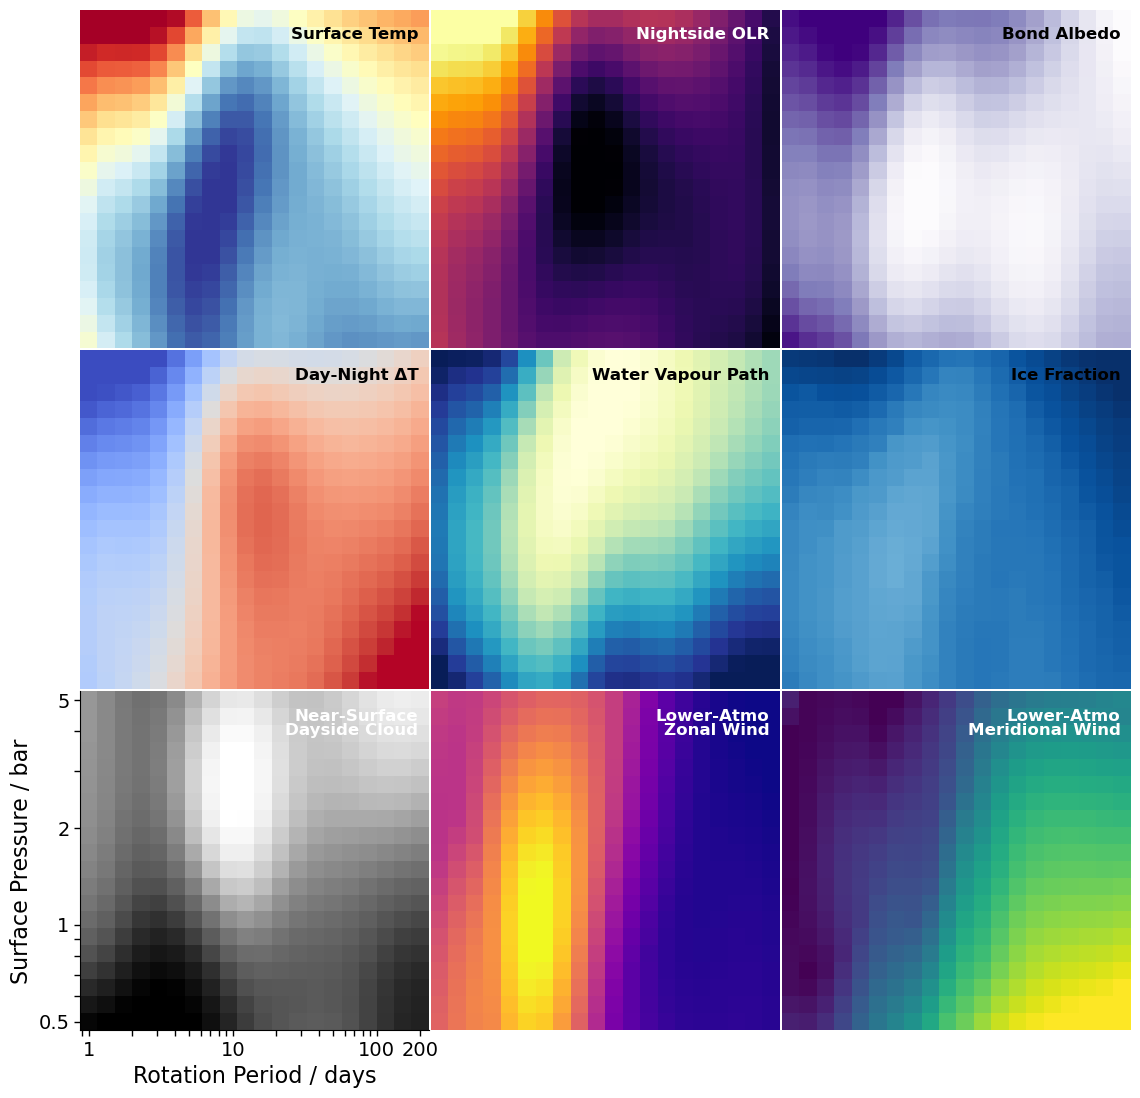

In [5]:
PANELS = [
    ("mean_surface_temperature", "Surface Temp", "RdYlBu_r", "black", (2, 98)),
    ("mean_nightside_olr", "Nightside OLR", "inferno", "white", (2, 98)),
    ("bond_albedo", "Bond Albedo", "Purples_r", "black", (2, 98)),
    ("day_night_temp_diff", "Day-Night ΔT", "coolwarm", "black", (2, 98)),
    ("global_mean_wvp", "Water Vapour Path", "YlGnBu", "black", (2, 98)),
    ("global_ice_fraction", "Ice Fraction", "Blues_r", "black", (1, 99)),
    ("near_surface_dayside_cloud_fraction", "Near-Surface\nDayside Cloud", "Greys_r", "white", (2, 98)),
    ("max_zonal_mean_zonal_wind", "Lower-Atmo\nZonal Wind", "plasma", "white", (2, 98)),
    ("max_abs_zonal_mean_meridional_wind", "Lower-Atmo\nMeridional Wind", "viridis", "white", (2, 98)),
]


def center_to_edges(values):
    lv = np.log10(np.asarray(values, dtype=np.float64))
    edges = np.empty(values.size + 1, dtype=np.float64)
    edges[1:-1] = 0.5 * (lv[:-1] + lv[1:])
    edges[0] = lv[0] - 0.5 * (lv[1] - lv[0])
    edges[-1] = lv[-1] + 0.5 * (lv[-1] - lv[-2])
    return 10 ** edges


def robust_range(values, low, high):
    vmin, vmax = np.nanpercentile(values, [low, high])
    return (float(vmin), float(vmax + 1.0e-6)) if np.isclose(vmin, vmax) else (float(vmin), float(vmax))


start = time.perf_counter()
xe, ye = center_to_edges(P_ROT_DAYS), center_to_edges(P0_BAR)
fig, axes = plt.subplots(3, 3, figsize=(11.6, 11.2), sharex=True, sharey=True, facecolor="white")
fig.subplots_adjust(left=0.09, right=0.996, bottom=0.085, top=0.996, wspace=0.006, hspace=0.006)

for ax, (field, label, cmap, label_color, pct) in zip(axes.flat, PANELS):
    z = metrics[field]
    vmin, vmax = robust_range(z, *pct)
    if field == "global_ice_fraction":
        vmax = 1.0
    ax.pcolormesh(xe, ye, z, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.text(
        0.97, 0.95, label, transform=ax.transAxes,
        ha="right", va="top", color=label_color,
        fontsize=12, fontweight="bold", linespacing=0.95,
    )
    ax.tick_params(which="both", bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False, length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

axis = axes[2, 0]
axis.tick_params(which="both", bottom=True, left=True, labelbottom=True, labelleft=True, colors="black", labelsize=14, length=4, width=1.0)
axis.xaxis.set_major_locator(ticker.FixedLocator([1.0, 10.0, 100.0, 200.0]))
axis.yaxis.set_major_locator(ticker.FixedLocator([0.5, 1.0, 2.0, 5.0]))
axis.xaxis.set_major_formatter(ticker.FixedFormatter(["1", "10", "100", "200"]))
axis.yaxis.set_major_formatter(ticker.FixedFormatter(["0.5", "1", "2", "5"]))
axis.set_xlabel("Rotation Period / days", fontsize=16)
axis.set_ylabel("Surface Pressure / bar", fontsize=16)
for spine in axis.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

plot_seconds = time.perf_counter() - start
print(f"plot time: {plot_seconds:.2f} s")
print(f"total notebook workload: {predict_seconds + metric_seconds + plot_seconds:.2f} s")
plt.show()
